# 05 — Prédiction du churn

**Question métier :** quels clients risquent de ne plus acheter dans les 90 prochains jours, pour cibler une campagne de rétention ?

**Définition du churn :** un client ayant au moins un achat avant la date d'observation (*snapshot*) est dit churné s'il **n'achète pas dans les 90 jours suivants**.

**Protocole (anti-fuite de données) :**
- Les features sont calculées **uniquement sur l'historique antérieur au snapshot** (fonction SQL `warehouse.fn_Churn_Features`, `sql/06_churn_features.sql`).
- **Validation temporelle** plutôt qu'un split aléatoire : le modèle est entraîné sur le snapshot du **1er septembre 2024** et évalué sur celui du **1er décembre 2024**, c'est-à-dire sur une période future qu'il n'a jamais vue — exactement la situation de production.
- Le modèle final est ré-entraîné sur le snapshot le plus récent dont le label est connu, puis utilisé pour scorer les clients **à la dernière date disponible**.

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score, roc_curve
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from src.config import RANDOM_STATE
from src.db import get_engine, read_sql
from src.plotting import MUTED, PALETTE, PRIMARY, percent, set_style

set_style()
engine = get_engine()

TRAIN_SNAPSHOT = "2024-09-01"
TEST_SNAPSHOT = "2024-12-01"
WINDOW_DAYS = 90
TARGET = "Churned"
FEATURES = [
    "Recency_Days", "Tenure_Days", "Frequency", "Monetary_USD", "Avg_Line_Value_USD",
    "Discount_Usage_Rate", "Distinct_Categories", "Total_Units",
    "Orders_Last_90d", "Orders_Prior_90d", "Momentum",
]


def load_snapshot(snapshot_date: str) -> pd.DataFrame:
    return read_sql(
        "SELECT * FROM warehouse.fn_Churn_Features(:snapshot, :window)",
        engine, snapshot=snapshot_date, window=WINDOW_DAYS,
    )

## 1. Données

In [2]:
train = load_snapshot(TRAIN_SNAPSHOT)
test = load_snapshot(TEST_SNAPSHOT)

X_train, y_train = train[FEATURES], train[TARGET].astype(int)
X_test, y_test = test[FEATURES], test[TARGET].astype(int)

pd.DataFrame({
    "Clients": [len(train), len(test)],
    "Taux de churn": [y_train.mean(), y_test.mean()],
    "Fenêtre du label": [f"{TRAIN_SNAPSHOT} + {WINDOW_DAYS} j", f"{TEST_SNAPSHOT} + {WINDOW_DAYS} j"],
}, index=["Entraînement", "Test"]).style.format({"Clients": "{:,}", "Taux de churn": "{:.1%}"})

,Clients,Taux de churn,Fenêtre du label
Entraînement,"1,138,615",67.2%,2024-09-01 + 90 j
Test,"1,211,337",63.1%,2024-12-01 + 90 j


Le churn est **majoritaire** (la plupart des clients n'achètent pas chaque trimestre dans la mode) : l'**accuracy est donc trompeuse** — prédire « churn » pour tout le monde donnerait déjà une accuracy égale au taux de churn. On évalue plutôt la capacité à **classer** les clients par risque :
- **ROC-AUC** : probabilité qu'un churner soit mieux classé qu'un client actif (0,5 = hasard) ;
- **PR-AUC** : précision moyenne sur la classe churn, à comparer au taux de churn ;
- **Lift du top 10 %** : combien de fois plus de churners dans les 10 % de clients les plus à risque que dans la population — c'est ce qui compte pour une campagne à budget limité.

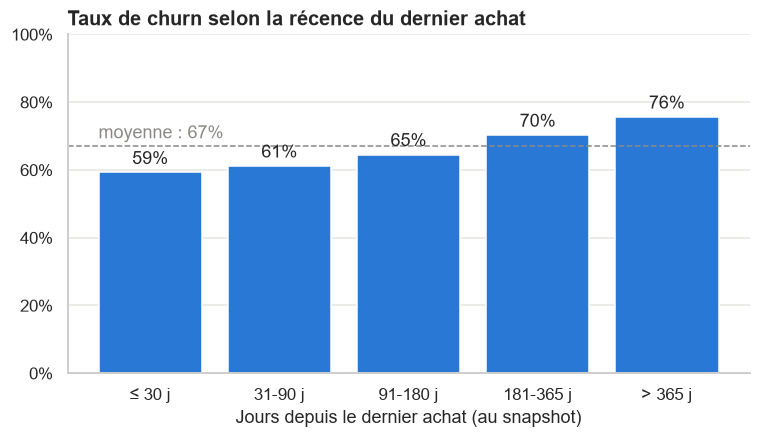

In [3]:
recency_buckets = pd.cut(train["Recency_Days"], bins=[-1, 30, 90, 180, 365, np.inf],
                         labels=["≤ 30 j", "31-90 j", "91-180 j", "181-365 j", "> 365 j"])
churn_by_recency = y_train.groupby(recency_buckets, observed=True).mean()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(churn_by_recency.index.astype(str), churn_by_recency.values, color=PRIMARY)
ax.bar_label(bars, labels=[f"{v:.0%}" for v in churn_by_recency.values], padding=3)
ax.axhline(y_train.mean(), color=MUTED, linestyle="--", linewidth=1)
ax.text(-0.4, y_train.mean() + 0.01, f"moyenne : {y_train.mean():.0%}", va="bottom", color=MUTED)
ax.yaxis.set_major_formatter(percent())
ax.set_ylim(0, 1)
ax.set_title("Taux de churn selon la récence du dernier achat")
ax.set_xlabel("Jours depuis le dernier achat (au snapshot)")
ax.grid(axis="x", visible=False)
plt.show()

Le taux de churn augmente bien avec la récence (59 % pour les clients ayant acheté dans les 30 derniers jours, 76 % au-delà d'un an), mais **l'écart est faible** : même les clients les plus récents churnent majoritairement. La récence sert de **baseline métier** : un modèle de machine learning n'est utile que s'il fait mieux qu'une simple règle « trier par récence ».

## 2. Modèles et évaluation sur la période de test

In [4]:
def evaluate(y_true: pd.Series, scores: np.ndarray) -> dict:
    y_true = y_true.to_numpy()
    top_decile = scores >= np.quantile(scores, 0.9)
    return {
        "ROC-AUC": roc_auc_score(y_true, scores),
        "PR-AUC": average_precision_score(y_true, scores),
        "Lift top 10 %": y_true[top_decile].mean() / y_true.mean(),
    }


models = {
    "Régression logistique": make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=1_000, random_state=RANDOM_STATE)
    ),
    "Gradient Boosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}

scores = {"Baseline : récence seule": X_test["Recency_Days"].to_numpy()}
for name, model in models.items():
    model.fit(X_train, y_train)
    scores[name] = model.predict_proba(X_test)[:, 1]

results = pd.DataFrame({name: evaluate(y_test, s) for name, s in scores.items()}).T
results.loc["Aléatoire"] = {"ROC-AUC": 0.5, "PR-AUC": y_test.mean(), "Lift top 10 %": 1.0}
results.style.format("{:.3f}")

,ROC-AUC,PR-AUC,Lift top 10 %
Baseline : récence seule,0.576,0.689,1.168
Régression logistique,0.640,0.723,1.192
Gradient Boosting,0.640,0.723,1.193
Aléatoire,0.500,0.631,1.000


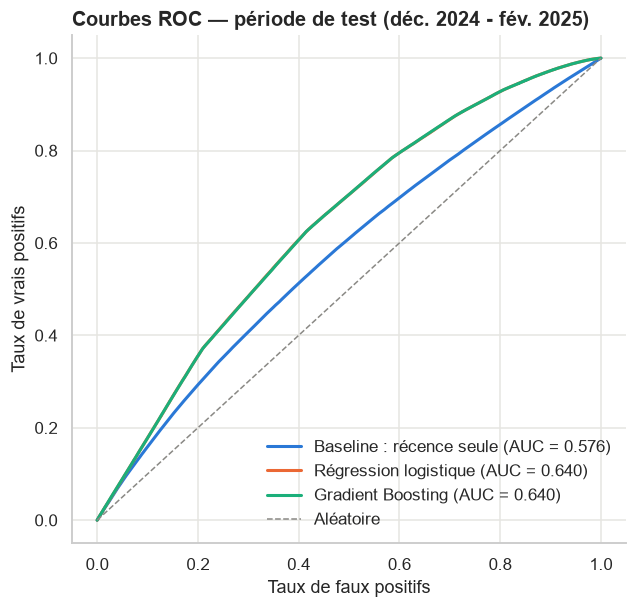

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 6))
for color, (name, s) in zip(PALETTE, scores.items()):
    fpr, tpr, _ = roc_curve(y_test, s)
    ax.plot(fpr, tpr, color=color, label=f"{name} (AUC = {roc_auc_score(y_test, s):.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color=MUTED, linewidth=1, label="Aléatoire")
ax.set_title("Courbes ROC — période de test (déc. 2024 - fév. 2025)")
ax.set_xlabel("Taux de faux positifs")
ax.set_ylabel("Taux de vrais positifs")
ax.legend(frameon=False, loc="lower right")
plt.show()

**Lecture des résultats (période de test, jamais vue à l'entraînement) :**
- Les deux modèles atteignent une **ROC-AUC de 0,64**, nettement au-dessus du hasard (0,50) et de la baseline « récence seule » (0,58) : le modèle apporte une information réelle.
- **Régression logistique et Gradient Boosting font jeu égal** : la relation est essentiellement monotone et le modèle non linéaire n'apporte rien. À performance égale, le modèle le plus simple et le plus interprétable est retenu.
- Le gain opérationnel reste **modeste** : les 10 % de clients les plus à risque contiennent 1,19 fois plus de churners que la moyenne. Avec un churn de base de 63 %, la marge d'un ciblage est limitée par construction (le lift maximal possible est de 1,58).
- Pour mémoire, la première version du projet (split aléatoire) obtenait la même ROC-AUC mais évaluait les modèles avec un seuil de 0,5 : leur F1 (0,772) était **inférieur** à celui d'une prédiction naïve « tout le monde churne » (0,774). D'où le choix de métriques de classement dans cette version.

**Pourquoi le seuil 0,5 n'est pas utilisé :** le seuil de décision dépend du budget de la campagne. En pratique on cible les *k* % de clients au score le plus élevé ; le lift du top 10 % mesure directement la valeur de ce ciblage.

## 3. Quelles variables comptent ?

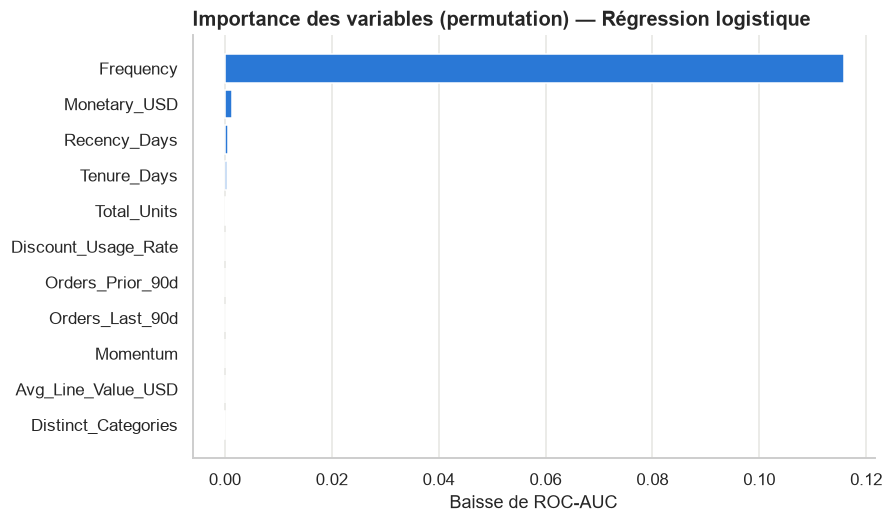

In [6]:
best_name = results.drop(index=["Aléatoire", "Baseline : récence seule"])["ROC-AUC"].idxmax()
best_model = models[best_name]

# Importance par permutation (sur un échantillon du test) : baisse de ROC-AUC quand on mélange une variable.
sample = X_test.sample(100_000, random_state=RANDOM_STATE)
importance = permutation_importance(
    best_model, sample, y_test.loc[sample.index], scoring="roc_auc",
    n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1,
)
importance = pd.Series(importance.importances_mean, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance.index, importance.values, color=PRIMARY)
ax.set_title(f"Importance des variables (permutation) — {best_name}")
ax.set_xlabel("Baisse de ROC-AUC")
ax.grid(axis="y", visible=False)
plt.show()

**La fréquence d'achat porte presque tout le signal** : plus un client a commandé, moins il churne. Les autres variables, y compris la récence, n'ajoutent presque rien une fois la fréquence connue. Les variables de dynamique récente (`Orders_Last_90d`, `Momentum`) et l'usage des remises sont inutiles, ce qui est cohérent avec des données synthétiques où le comportement d'achat est largement aléatoire.

Méthode : l'importance par permutation est préférée à `feature_importances_` des arbres, biaisée vers les variables continues. `Frequency`, `Total_Units` et `Monetary_USD` étant très corrélées, l'importance se concentre sur l'une d'elles ; aucune ne doit être lue comme une cause.

## 4. Scoring des clients à la dernière date disponible

In [7]:
latest_date = read_sql(
    "SELECT MAX(d.[Date]) AS Last_Date FROM warehouse.Fact_Sales f JOIN warehouse.Dim_Date d ON d.Date_Key = f.Date_Key",
    engine,
).iloc[0, 0]
to_score = load_snapshot(str(latest_date))

# Ré-entraînement sur le snapshot labellisé le plus récent (période de test).
final_model = clone(best_model).fit(X_test, y_test)

predictions = to_score[["Customer_Key", "Snapshot_Date"]].copy()
predictions["Churn_Probability"] = final_model.predict_proba(to_score[FEATURES])[:, 1]
predictions["Risk_Decile"] = pd.qcut(predictions["Churn_Probability"].rank(method="first"), 10, labels=range(1, 11)).astype(int)
predictions["Model"] = best_name

predictions.to_sql("Customer_Churn_Predictions", engine, schema="warehouse",
                   if_exists="replace", index=False, chunksize=5_000)
print(f"{len(predictions):,} clients scorés au {latest_date} -> warehouse.Customer_Churn_Predictions")
predictions["Churn_Probability"].describe()

1,283,707 clients scorés au 2025-03-18 -> warehouse.Customer_Churn_Predictions


count    1.283707e+06
mean     6.053045e-01
std      1.397303e-01
min      1.735179e-03
25%      5.416101e-01
50%      6.354877e-01
75%      7.329872e-01
max      7.622609e-01
Name: Churn_Probability, dtype: float64

`Risk_Decile = 10` correspond aux 10 % de clients les plus à risque : c'est la liste à transmettre à l'équipe CRM.

## Conclusions et limites

- **Méthodologie :** features calculées strictement avant le snapshot, validation sur une période future, comparaison à une baseline métier et métriques adaptées à une classe majoritaire. Le protocole est réutilisable tel quel sur des données réelles.
- **Performance modeste (ROC-AUC 0,64, lift de 1,19 sur le top 10 %)**, présentée telle quelle : le dataset est synthétique, les comportements d'achat y sont en grande partie aléatoires, et seules des variables transactionnelles sont disponibles. Des données de navigation, d'emailing ou de service client amélioreraient fortement le modèle.
- **Définition du churn à 90 jours** : la majorité des clients n'achète pas chaque trimestre ; une fenêtre plus longue (180 jours), alignée sur le délai médian entre deux commandes, donnerait une définition plus proche du « vrai » churn.
- **Saisonnalité** : la fenêtre d'entraînement (sept.-nov.) et celle de test (déc.-fév., avec les fêtes) n'ont pas le même comportement ; la ROC-AUC y est peu sensible, mais pas la calibration des probabilités.
- **Ne pas calculer un « taux de churn par segment RFM »** en croisant le label historique avec les segments actuels (raisonnement circulaire, voir notebook 04). La page Churn du dashboard doit utiliser `Churn_Probability` issue de ce notebook.